# Lab Instructions

You have been hired by James Cameron to create profiles of two characters for a reboot of the Titanic Movie: one that is most likely to survive the sinking and one that is least likely to survive.  Mr. Cameron wants this reboot to be as historically accurate as possible, so your profile of each character should be backed up with data and visualizations.

Each character profile should include information on their:
* Age, fare
* Sex
* Passenger class
* Travel companions (including both parents/children and siblings/spouse)
* Port of departure (indicated by the Embarked feature in the dataset)

For quantitative features like `Age` and `Fare`, you will need to use the `.loc` method we learned in class (or something similar) to place individuals in categories.  How you choose to do this is up to you, but make sure you explain your reasoning.

You should include at least one visualization for each element of the character profile (age, sex, passenger class, etc.) as evidence.

After you have developed your two character profiles, use your Pandas data wrangling skills to identify at least one real passenger in the dataset that fits each profile.  Print out the names of these individuals.  Look them up in [Encyclopeida Titanica](https://www.encyclopedia-titanica.org/) (or a similar resource).  

Tell Mr. Cameron at least one thing about the real passengers who fit your two character profiles that you learned from an external resource.  You need one interesting fact about a person who fits the profile of "most likely to survive" and one interesting fact about a person who fits the profile of "least likely to surivive".  



In [33]:
import pandas as pd

df = pd.read_csv('titanic_passengers.csv')

df.head(25)

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S
5,6,0,3,"Moran, Mr. James",male,NaN,0,0,330877,8.4583,NaN,Q
6,7,0,1,"McCarthy, Mr. Timothy J",male,54.0,0,0,17463,51.8625,E46,S
7,8,0,3,"Palsson, Master. Gosta Leonard",male,2.0,3,1,349909,21.0750,NaN,S
8,9,1,3,"Johnson, Mrs. Oscar W (Elisabeth Vilhelmina Berg)",female,27.0,0,2,347742,11.1333,NaN,S
9,10,1,2,"Nasser, Mrs. Nicholas (Adele Achem)",female,14.0,1,0,237736,30.0708,NaN,C


In [5]:
df['Fare'].describe()

count    891.000000
mean      32.204208
std       49.693429
min        0.000000
25%        7.910400
50%       14.454200
75%       31.000000
max      512.329200
Name: Fare, dtype: float64

In [57]:
df['AgeGroup'] = 'Unknown'

df.loc[df['Age'] < 13, 'AgeGroup'] = 'Child'
df.loc[(df['Age'] >= 13) & (df['Age'] < 20), 'AgeGroup'] = 'Teen'
df.loc[(df['Age'] >= 20) & (df['Age'] < 40), 'AgeGroup'] = 'Young Adult'
df.loc[(df['Age'] >= 40) & (df['Age'] < 60), 'AgeGroup'] = 'Middle Aged'
df.loc[df['Age'] >= 60, 'AgeGroup'] = 'Senior'

In [ ]:
I used the Pandas .loc method to categorize continuous variables such as Age and Fare into organized groups.
This made it easier to compare survival trends across categories 

In [58]:
df['FareGroup'] = 'Unknown'

q1 = df['Fare'].quantile(0.25)
q2 = df['Fare'].quantile(0.50)
q3 = df['Fare'].quantile(0.75)

df.loc[df['Fare'] <= q1, 'FareGroup'] = 'Low'
df.loc[(df['Fare'] > q1) & (df['Fare'] <= q2), 'FareGroup'] = 'Medium'
df.loc[(df['Fare'] > q2) & (df['Fare'] <= q3), 'FareGroup'] = 'High'
df.loc[df['Fare'] > q3, 'FareGroup'] = 'Very High'

In [59]:
print("Sex survival rates:")
print(df.groupby('Sex')['Survived'].mean().sort_values(ascending=False))

print("\nPassenger class survival rates:")
print(df.groupby('Pclass')['Survived'].mean().sort_values(ascending=False))

print("\nAge group survival rates:")
print(df.groupby('AgeGroup')['Survived'].mean().sort_values(ascending=False))

print("\nFare group survival rates:")
print(df.groupby('FareGroup')['Survived'].mean().sort_values(ascending=False))

print("\nTravel companion group survival rates:")
print(df.groupby('CompanionGroup')['Survived'].mean().sort_values(ascending=False))

print("\nPort of departure survival rates:")
print(df.groupby('Embarked')['Survived'].mean().sort_values(ascending=False))

Sex survival rates:
Sex
female    0.742038
male      0.188908
Name: Survived, dtype: float64

Passenger class survival rates:
Pclass
1    0.629630
2    0.472826
3    0.242363
Name: Survived, dtype: float64

Age group survival rates:
AgeGroup
Child          0.579710
Teen           0.410526
Middle Aged    0.394161
Young Adult    0.387597
Unknown        0.293785
Senior         0.269231
Name: Survived, dtype: float64

Fare group survival rates:
FareGroup
Very High    0.581081
High         0.454955
Medium       0.303571
Low          0.197309
Name: Survived, dtype: float64

Travel companion group survival rates:
CompanionGroup
Small group    0.562738
Large group    0.340659
Alone          0.303538
Name: Survived, dtype: float64

Port of departure survival rates:
Embarked
C    0.553571
Q    0.389610
S    0.336957
Name: Survived, dtype: float64


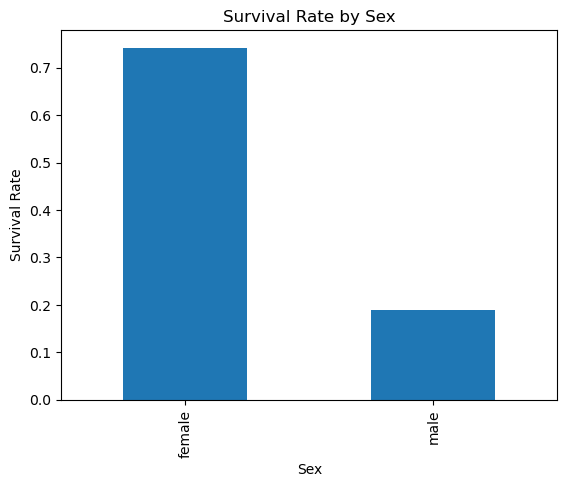

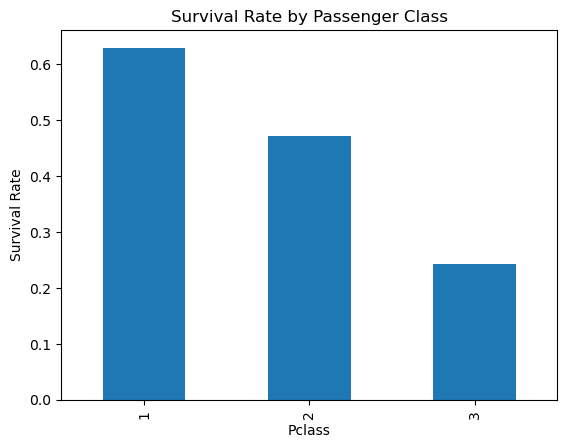

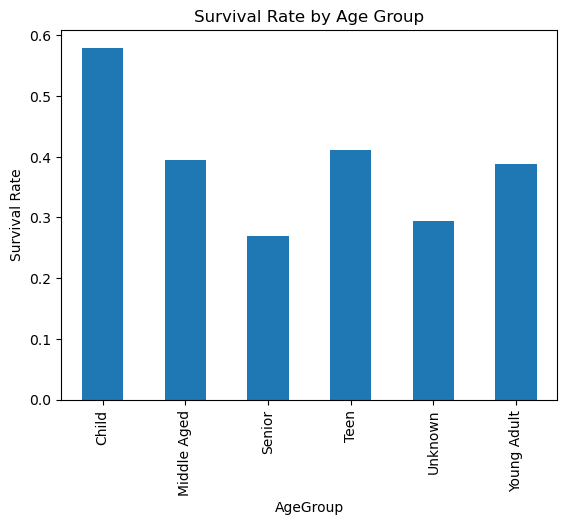

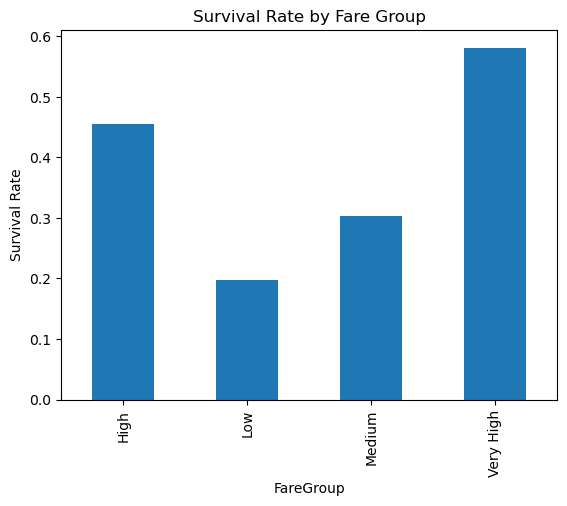

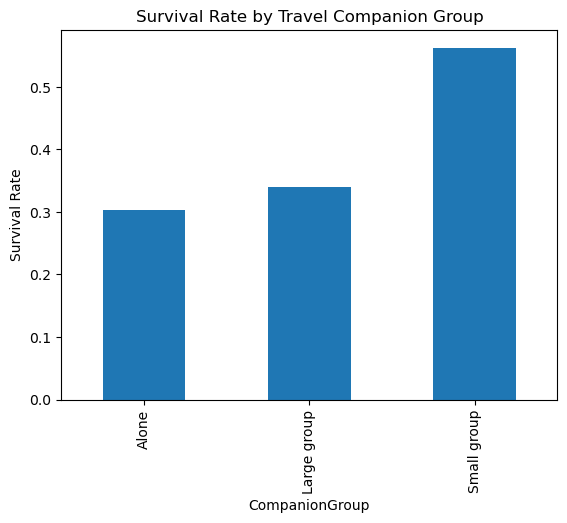

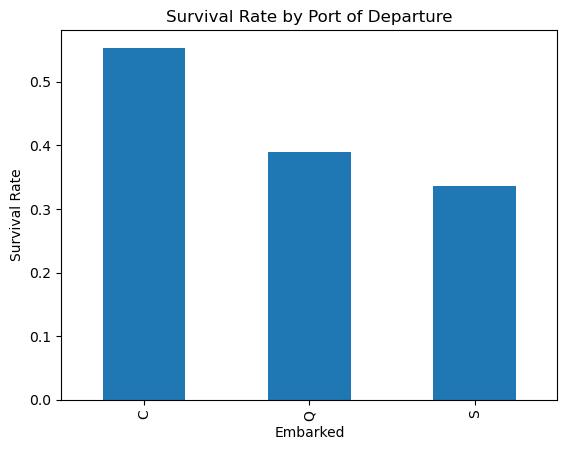

In [54]:
df.groupby('Sex')['Survived'].mean().plot(kind='bar', title='Survival Rate by Sex')
plt.ylabel('Survival Rate')
plt.show()

df.groupby('Pclass')['Survived'].mean().plot(kind='bar', title='Survival Rate by Passenger Class')
plt.ylabel('Survival Rate')
plt.show()

df.groupby('AgeGroup')['Survived'].mean().plot(kind='bar', title='Survival Rate by Age Group')
plt.ylabel('Survival Rate')
plt.show()

df.groupby('FareGroup')['Survived'].mean().plot(kind='bar', title='Survival Rate by Fare Group')
plt.ylabel('Survival Rate')
plt.show()

df.groupby('CompanionGroup')['Survived'].mean().plot(kind='bar', title='Survival Rate by Travel Companion Group')
plt.ylabel('Survival Rate')
plt.show()

df.groupby('Embarked')['Survived'].mean().plot(kind='bar', title='Survival Rate by Port of Departure')
plt.ylabel('Survival Rate')
plt.show()

In [48]:
most_likely = df[
    (df['Sex'] == 'female') &
    (df['Pclass'] == 1)
]

least_likely = df[
    (df['Sex'] == 'male') &
    (df['Pclass'] == 3)
]

print("Profile 1 Match:")
print(most_likely['Name'].iloc[0])

print("\nProfile 2 Match:")
print(least_likely['Name'].iloc[0])

Profile 1 Match:
Cumings, Mrs. John Bradley (Florence Briggs Thayer)

Profile 2 Match:
Braund, Mr. Owen Harris


In [60]:
most_match = df[df['Name'] == 'Cumings, Mrs. John Bradley (Florence Briggs Thayer)'].iloc[0]
least_match = df[df['Name'] == 'Braund, Mr. Owen Harris'].iloc[0]

print("MOST LIKELY TO SURVIVE CHARACTER PROFILE")
print(f"Name: {most_match['Name']}")
print(f"Sex: {most_match['Sex']}")
print(f"Age: {most_match['Age']}")
print(f"Age Group: {most_match['AgeGroup']}")
print(f"Passenger Class: {most_match['Pclass']}")
print(f"Fare: {most_match['Fare']}")
print(f"Fare Group: {most_match['FareGroup']}")
print(f"Siblings/Spouse aboard: {most_match['SibSp']}")
print(f"Parents/Children aboard: {most_match['Parch']}")
print(f"Total Travel Companions: {most_match['TravelCompanions']}")
print(f"Companion Group: {most_match['CompanionGroup']}")
print(f"Port of Departure: {most_match['Embarked']}")
print(f"Survived: {most_match['Survived']}")

print("\nLEAST LIKELY TO SURVIVE CHARACTER PROFILE")
print(f"Name: {least_match['Name']}")
print(f"Sex: {least_match['Sex']}")
print(f"Age: {least_match['Age']}")
print(f"Age Group: {least_match['AgeGroup']}")
print(f"Passenger Class: {least_match['Pclass']}")
print(f"Fare: {least_match['Fare']}")
print(f"Fare Group: {least_match['FareGroup']}")
print(f"Siblings/Spouse aboard: {least_match['SibSp']}")
print(f"Parents/Children aboard: {least_match['Parch']}")
print(f"Total Travel Companions: {least_match['TravelCompanions']}")
print(f"Companion Group: {least_match['CompanionGroup']}")
print(f"Port of Departure: {least_match['Embarked']}")
print(f"Survived: {least_match['Survived']}")

MOST LIKELY TO SURVIVE CHARACTER PROFILE
Name: Cumings, Mrs. John Bradley (Florence Briggs Thayer)
Sex: female
Age: 38.0
Age Group: Young Adult
Passenger Class: 1
Fare: 71.2833
Fare Group: Very High
Siblings/Spouse aboard: 1
Parents/Children aboard: 0
Total Travel Companions: 1
Companion Group: Small group
Port of Departure: C
Survived: 1

LEAST LIKELY TO SURVIVE CHARACTER PROFILE
Name: Braund, Mr. Owen Harris
Sex: male
Age: 22.0
Age Group: Young Adult
Passenger Class: 3
Fare: 7.25
Fare Group: Low
Siblings/Spouse aboard: 1
Parents/Children aboard: 0
Total Travel Companions: 1
Companion Group: Small group
Port of Departure: S
Survived: 0


In [ ]:
He was a third-class male passenger which fits the least likely to survive profile.
He was a 22-year-old laborer from England traveling alone in third class. 
He boarded at Southampton and held a low-cost third-class ticket.
Owen did not survive the sinking. His death reflects how the disaster disproportionately 
affected immigrants and working-class passengers who were trying to build new lives in America.


In [ ]:
She was a first-class female passenger which fits the profile most likely to survive.
She boarded the Titanic with her husband John Bradley Cumings and traveled in Cabin C-85.
Her ticket cost £71 5s 8d was expensive for the time, consistant with first class.
Florence survived the disaster after being placed into Lifeboat 4 but her husband did not survive. 
Historical records show that after being rescued from Titanic, she later gave birth to a daughter named Elizabeth Cumings,
who eventually became one of the last living descendants of Titanic survivors connected to that voyage.